Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.varmax import VARMAX

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [3]:
df = pd.read_csv('/content/retail_sales_forecast_dataset.csv')

df.head()

,Transaction_ID,Date,Year,Month,Week,Day,Day_Of_Week,Quarter,Store_ID,Store_Type,...,Marketing_Spend,Weather_Condition,Economic_Index,Online_Orders,Returns,Customer_Satisfaction,Shipping_Time,Supplier_Rating,Sales_Amount,Demand_Level
0,315247,2023-01-01,2023,1,52,1,Sunday,1,ST088,Convenience Store,...,1909.90,Sunny,106.40,141,0,3.50,3,3.92,597.80,Medium
1,302305,2023-01-01,2023,1,52,1,Sunday,1,ST077,Hypermarket,...,3822.59,Rainy,86.72,47,0,4.04,4,2.92,440.51,Low
2,323122,2023-01-01,2023,1,52,1,Sunday,1,ST100,Convenience Store,...,2877.94,Cloudy,96.39,180,2,3.83,3,4.85,4233.12,High
3,301379,2023-01-01,2023,1,52,1,Sunday,1,ST088,Hypermarket,...,2606.41,Sunny,115.58,184,2,4.15,3,2.90,737.02,Medium
4,315984,2023-01-01,2023,1,52,1,Sunday,1,ST039,Hypermarket,...,4114.20,Rainy,91.96,120,2,3.73,3,3.42,2481.01,High


Total records (rows) and columns

In [5]:
print(df.shape)

(25000, 35)


Check Columns

In [6]:
print(df.columns)

Index(['Transaction_ID', 'Date', 'Year', 'Month', 'Week', 'Day', 'Day_Of_Week',
       'Quarter', 'Store_ID', 'Store_Type', 'Region', 'City', 'Product_ID',
       'Product_Category', 'Product_Subcategory', 'Brand', 'Units_Sold',
       'Unit_Price', 'Discount_Percent', 'Promotion', 'Holiday', 'Season',
       'Inventory_Level', 'Competitor_Price', 'Customer_Footfall',
       'Marketing_Spend', 'Weather_Condition', 'Economic_Index',
       'Online_Orders', 'Returns', 'Customer_Satisfaction', 'Shipping_Time',
       'Supplier_Rating', 'Sales_Amount', 'Demand_Level'],
      dtype='object')


Convert Date

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.sort_values('Date', inplace=True)

Aggregate Daily Data

In [10]:
daily_data = df.groupby('Date').agg({
    'Sales_Amount':'sum',
    'Units_Sold':'sum',
    'Discount_Percent':'mean',
    'Marketing_Spend':'mean',
    'Customer_Footfall':'sum',
    'Online_Orders':'sum',
    'Economic_Index':'mean'
})

daily_data.head()

,Sales_Amount,Units_Sold,Discount_Percent,Marketing_Spend,Customer_Footfall,Online_Orders,Economic_Index
Date,,,,,,,
2023-01-01,42812.15,519,13.095238,3148.608095,9748,3404,99.870476
2023-01-02,26749.82,347,8.076923,3849.893846,5380,1877,102.103077
2023-01-03,36196.71,332,8.214286,3517.077143,6572,1708,98.771429
2023-01-04,38633.80,516,10.000000,3624.630000,10187,2446,101.531000
2023-01-05,36992.87,460,11.136364,3370.584091,11660,3157,100.542273


Check Missing Values

In [11]:
daily_data.isnull().sum()

,0
Sales_Amount,0
Units_Sold,0
Discount_Percent,0
Marketing_Spend,0
Customer_Footfall,0
Online_Orders,0
Economic_Index,0


The isnull().sum() function was used to identify and count missing values in each variable before model training.
==========


In [12]:
daily_data = daily_data.fillna(method='ffill')

Replaces missing values using the previous valid observation.

| Step                    | Code                                | Purpose                                             |
| ----------------------- | ----------------------------------- | --------------------------------------------------- |
| Missing Value Detection | `daily_data.isnull().sum()`         | Identifies missing values in each column            |
| Missing Value Treatment | `daily_data.fillna(method='ffill')` | Replaces missing values using previous observations |
| Verification            | `daily_data.isnull().sum()`         | Confirms dataset is free from missing values        |


Define Endogenous Variables

In [13]:
endog = daily_data[
[
    'Sales_Amount',
    'Units_Sold'
]
]

Define Exogenous Variables

In [14]:
exog = daily_data[
[
    'Discount_Percent',
    'Marketing_Spend',
    'Customer_Footfall',
    'Online_Orders',
    'Economic_Index'
]
]

Visualize Sales

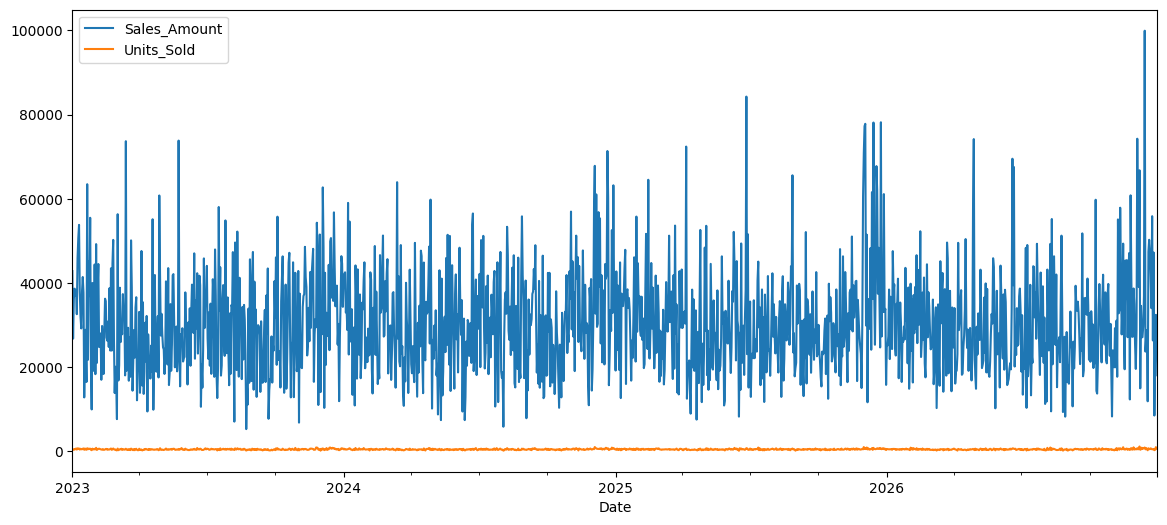

In [15]:
endog.plot(figsize=(14,6))

plt.show()

ADF Test Function

In [16]:
def adf_test(series):

    result = adfuller(series)

    print("ADF Statistic :", result[0])
    print("P-value :", result[1])

    if result[1] <= 0.05:
        print("Stationary")
    else:
        print("Non-Stationary")

ADF Test

In [17]:
for col in endog.columns:

    print("\nColumn :", col)

    adf_test(endog[col])


Column : Sales_Amount
ADF Statistic : -5.973439542725339
P-value : 1.9120933124983137e-07
Stationary

Column : Units_Sold
ADF Statistic : -5.295164055964108
P-value : 5.603374980244587e-06
Stationary


The Augmented Dickey-Fuller (ADF) test was performed to check whether the time-series data is stationary. Stationarity is a key requirement for VARMAX modeling because the statistical properties such as mean and variance should remain constant over time.
===========

| Step | Activity               | Outcome              |
| ---- | ---------------------- | -------------------- |
| 1    | Applied ADF Test       | Checked stationarity |
| 2    | Evaluated P-Value      | Compared with 0.05   |
| 3    | Sales_Amount           | Stationary           |
| 4    | Units_Sold             | Stationary           |
| 5    | Differencing Required? | ❌ No                 |

===========

Since both variables are already stationary:

❌ Do NOT run this step

endog_diff = endog.diff().dropna()

For dataset:

endog_final = endog

exog_final = exog

Use the original data directly.

Train-Test Split

In [18]:
train_size = int(len(endog) * 0.80)

endog_train = endog.iloc[:train_size]
endog_test = endog.iloc[train_size:]

exog_train = exog.iloc[:train_size]
exog_test = exog.iloc[train_size:]

print("Endog Train:", endog_train.shape)
print("Endog Test :", endog_test.shape)

print("Exog Train :", exog_train.shape)
print("Exog Test  :", exog_test.shape)

Endog Train: (1168, 2)
Endog Test : (293, 2)
Exog Train : (1168, 5)
Exog Test  : (293, 5)


Build VARMAX Model

In [19]:
from statsmodels.tsa.statespace.varmax import VARMAX

model = VARMAX(
    endog=endog_train,
    exog=exog_train,
    order=(2,1)
)

model

| Parameter       | Value                                                     | Purpose                                                |
| --------------- | --------------------------------------------------------- | ------------------------------------------------------ |
| Model Type      | VARMAX                                                    | Multivariate forecasting with external variables       |
| Endogenous Data | `endog_train`                                             | Variables to forecast (Sales_Amount, Units_Sold)       |
| Exogenous Data  | `exog_train`                                              | External factors (Discount, Marketing, Footfall, etc.) |
| AR Order (p)    | 2                                                         | Uses previous 2 observations                           |
| MA Order (q)    | 1                                                         | Uses previous 1 error term                             |
| Syntax          | `VARMAX(endog=endog_train, exog=exog_train, order=(2,1))` | Model definition                                       |


| Output            | Meaning                            |
| ----------------- | ---------------------------------- |
| VARMAX            | Model type selected                |
| endog=endog_train | Target variables loaded            |
| exog=exog_train   | External variables loaded          |
| order=(2,1)       | AR=2, MA=1                         |
| 0x79e470700380    | Memory address of the model object |
| Error?            | ❌ No error                         |
| Model Created?    | ✅ Yes                              |


Train Model

In [20]:
model_fit = model.fit(
    maxiter=1000,
    disp=False
)

print(model_fit.summary())

                                 Statespace Model Results                                 
Dep. Variable:     ['Sales_Amount', 'Units_Sold']   No. Observations:                 1168
Model:                                VARMAX(2,1)   Log Likelihood              -18852.358
                                      + intercept   AIC                          37758.716
Date:                            Sat, 20 Jun 2026   BIC                          37895.418
Time:                                    05:33:11   HQIC                         37810.279
Sample:                                01-01-2023                                         
                                     - 03-13-2026                                         
Covariance Type:                              opg                                         
Ljung-Box (L1) (Q):             4.06, 2.55   Jarque-Bera (JB):        234.41, 38.98
Prob(Q):                        0.04, 0.11   Prob(JB):                   0.00, 0.00
Heteroskedast

| Parameter                        | Coefficient | P-Value | Interpretation             |
| -------------------------------- | ----------: | ------: | -------------------------- |
| sqrt.var.Sales_Amount            |     9231.97 |   0.000 | ✅ Significant              |
| sqrt.cov.Sales_Amount.Units_Sold |        8.66 |   0.000 | ✅ Significant Relationship |
| sqrt.var.Units_Sold              |       63.23 |   0.000 | ✅ Significant              |

=======

Business Interpretation
Sales_Amount Variance

| Metric      | Value   |
| ----------- | ------- |
| Coefficient | 9231.97 |
| P-Value     | 0.000   |

Interpretation:

Sales Amount shows significant variation over time, indicating fluctuations in daily sales performance.

=======

Sales ↔ Units Sold Covariance

| Metric      | Value |
| ----------- | ----- |
| Coefficient | 8.66  |
| P-Value     | 0.000 |

Interpretation:

Sales Amount and Units Sold are positively related. When more units are sold, total sales revenue generally increases.

=======
Units Sold Variance

| Metric      | Value |
| ----------- | ----- |
| Coefficient | 63.23 |
| P-Value     | 0.000 |

nterpretation:

Units Sold also exhibits significant variation across time periods.
=======
Significance Table

| P-Value Condition | Result          |
| ----------------- | --------------- |
| P < 0.05          | Significant     |
| P > 0.05          | Not Significant |

| Parameter              | P-Value | Result        |
| ---------------------- | ------- | ------------- |
| Sales Variance         | 0.000   | ✅ Significant |
| Sales-Units Covariance | 0.000   | ✅ Significant |
| Units Variance         | 0.000   | ✅ Significant |

======



Model Information Table

In [21]:
summary_table = pd.DataFrame({
    'Metric':[
        'Log Likelihood',
        'AIC',
        'BIC',
        'HQIC'
    ],
    'Value':[
        model_fit.llf,
        model_fit.aic,
        model_fit.bic,
        model_fit.hqic
    ]
})

summary_table

,Metric,Value
0,Log Likelihood,-18852.357761
1,AIC,37758.715523
2,BIC,37895.417823
3,HQIC,37810.278865


| Metric         | Interpretation                                                                             |
| -------------- | ------------------------------------------------------------------------------------------ |
| Log Likelihood | Measures how well the model fits the data. Higher values indicate better fit.              |
| AIC            | Used for model selection. Lower AIC indicates a better balance between fit and complexity. |
| BIC            | Similar to AIC but applies a stronger penalty for model complexity.                        |
| HQIC           | Another model selection criterion balancing fit and simplicity.                            |

=====
| Metric | Formula Idea                            | Rule            |
| ------ | --------------------------------------- | --------------- |
| AIC    | Model Fit + Complexity Penalty          | Lower is Better |
| BIC    | Model Fit + Strong Complexity Penalty   | Lower is Better |
| HQIC   | Model Fit + Moderate Complexity Penalty | Lower is Better |

====
| Metric | Expansion                          | Developed By                | Purpose                                                    |
| ------ | ---------------------------------- | --------------------------- | ---------------------------------------------------------- |
| AIC    | Akaike Information Criterion       | Hirotugu Akaike             | Select the best forecasting model                          |
| BIC    | Bayesian Information Criterion     | Gideon Schwarz              | Select the best model with stronger penalty for complexity |
| HQIC   | Hannan–Quinn Information Criterion | Edward Hannan & Barry Quinn | Balance between AIC and BIC                                |


Forecast Test Data

In [22]:
forecast = model_fit.forecast(
    steps=len(endog_test),
    exog=exog_test
)

forecast.head()

,Sales_Amount,Units_Sold
2026-03-14,34172.723076,555.334325
2026-03-15,34247.668396,504.943444
2026-03-16,38119.049001,558.508489
2026-03-17,35266.845258,498.515747
2026-03-18,25850.023949,335.629828


Calculate MAE

In [23]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(
    endog_test['Sales_Amount'],
    forecast['Sales_Amount']
)

print("MAE :", mae)

MAE : 7424.842700084956


Calculate RMSE

In [24]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        endog_test['Sales_Amount'],
        forecast['Sales_Amount']
    )
)

print("RMSE :", rmse)

RMSE : 9718.662881370523


Metrics Table

In [25]:
metrics_table = pd.DataFrame({
    'Metric':['MAE','RMSE'],
    'Value':[mae, rmse]
})

metrics_table

,Metric,Value
0,MAE,7424.842700
1,RMSE,9718.662881


MAE (Mean Absolute Error)

Expansion:

Mean Absolute Error

Formula:

MAE = Average of |Actual - Forecast|

Result:

7424.84

Meaning:

On average, the model's sales prediction differs from actual sales by approximately 7425 units/rupees.

=========

RMSE (Root Mean Squared Error)

Expansion:

Root Mean Squared Error

Formula:

RMSE = √(Average of Squared Errors)

Your Result:

9718.66

Meaning:

Larger forecasting errors are penalized more heavily. The overall prediction error is approximately 9719 units/rupees.

**Project Result Table**

| Item                 | Result                                                             |
| -------------------- | ------------------------------------------------------------------ |
| Model                | VARMAX(2,1)                                                        |
| Dataset              | Retail Sales Forecast Dataset                                      |
| Endogenous Variables | Sales_Amount, Units_Sold                                           |
| Exogenous Variables  | Discount, Marketing Spend, Footfall, Online Orders, Economic Index |
| ADF Test             | Stationary                                                         |
| Differencing         | Not Required                                                       |
| Log Likelihood       | -18852.36                                                          |
| AIC                  | 37758.72                                                           |
| BIC                  | 37895.42                                                           |
| HQIC                 | 37810.28                                                           |
| MAE                  | 7424.84                                                            |
| RMSE                 | 9718.66                                                            |


Actual vs Forecast Graph

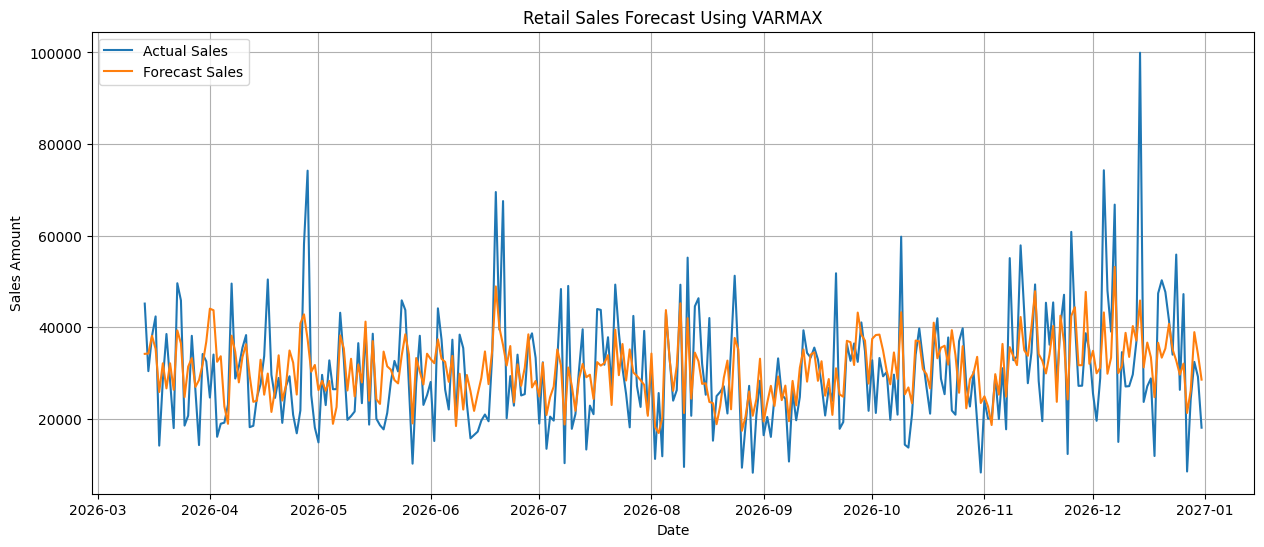

In [26]:
forecast.index = endog_test.index

plt.figure(figsize=(15,6))

plt.plot(
    endog_test.index,
    endog_test['Sales_Amount'],
    label='Actual Sales'
)

plt.plot(
    forecast.index,
    forecast['Sales_Amount'],
    label='Forecast Sales'
)

plt.title(
    'Retail Sales Forecast Using VARMAX'
)

plt.xlabel('Date')
plt.ylabel('Sales Amount')

plt.legend()
plt.grid(True)

plt.show()

| Observation                               | Interpretation                      |
| ----------------------------------------- | ----------------------------------- |
| Forecast follows trend                    | Model learned sales behavior        |
| Forecast smoother                         | Model captures average pattern      |
| Large spikes missed                       | Extreme events difficult to predict |
| Forecast close to actual most of the time | Model performance is reasonable     |


Correlation Heatmap

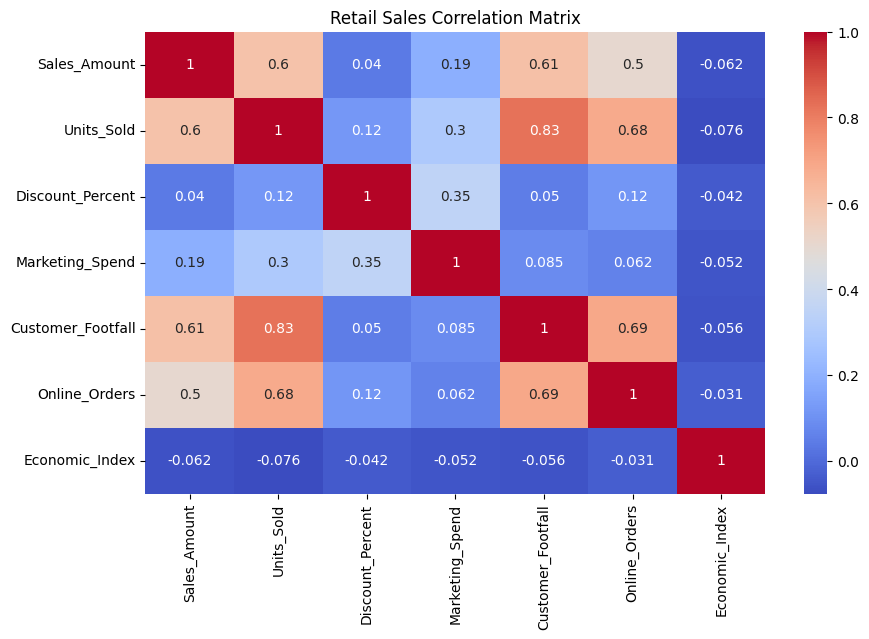

In [27]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.heatmap(
    daily_data.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title(
    'Retail Sales Correlation Matrix'
)

plt.show()

| Color                 | Correlation Range | Meaning                           |
| --------------------- | ----------------- | --------------------------------- |
| 🔴 Dark Red           | +0.80 to +1.00    | Very Strong Positive Relationship |
| 🟠 Light Red / Orange | +0.40 to +0.79    | Moderate Positive Relationship    |
| ⚪ White / Light Grey  | Around 0          | No Significant Relationship       |
| 🔵 Light Blue         | -0.10 to -0.40    | Weak Negative Relationship        |
| 🔵 Dark Blue          | -0.40 to -1.00    | Strong Negative Relationship      |

==========

| Correlation Value | Relationship      |
| ----------------- | ----------------- |
| +1.0              | Perfect Positive  |
| +0.7 to +0.9      | Strong Positive   |
| +0.4 to +0.7      | Moderate Positive |
| +0.1 to +0.4      | Weak Positive     |
| 0                 | No Relationship   |
| -0.1 to -0.4      | Weak Negative     |
| -0.4 to -0.7      | Moderate Negative |
| -0.7 to -1.0      | Strong Negative   |

==========

| Variables                         | Correlation | Color         | Interpretation         |
| --------------------------------- | ----------- | ------------- | ---------------------- |
| Units_Sold ↔ Customer_Footfall    | 0.83        | 🔴 Dark Red   | Very Strong Positive   |
| Customer_Footfall ↔ Online_Orders | 0.69        | 🟠 Orange/Red | Strong Positive        |
| Sales_Amount ↔ Customer_Footfall  | 0.61        | 🟠 Orange     | Moderate Positive      |
| Sales_Amount ↔ Discount_Percent   | 0.04        | ⚪ Near White  | Very Weak Relationship |
| Economic_Index ↔ Sales_Amount     | -0.06       | 🔵 Light Blue | Very Weak Negative     |


Future 7-Day Forecast
Create future external variables:

In [28]:
future_exog = pd.DataFrame({
    'Discount_Percent':[10]*7,
    'Marketing_Spend':[5000]*7,
    'Customer_Footfall':[200]*7,
    'Online_Orders':[100]*7,
    'Economic_Index':[100]*7
})

| Variable          | Value Used | Meaning                    |
| ----------------- | ---------: | -------------------------- |
| Discount_Percent  |         10 | 10% discount offered       |
| Marketing_Spend   |       5000 | ₹5,000 marketing budget    |
| Customer_Footfall |        200 | Expected 200 customers     |
| Online_Orders     |        100 | Expected 100 online orders |
| Economic_Index    |        100 | Stable economic condition  |

========

VARMAX requires future values of external variables (X) before forecasting future sales.

Future Sales Forecast
        ↓
Needs Future Discount
Needs Future Marketing Spend
Needs Future Footfall
Needs Future Online Orders
Needs Future Economic Index

Without these values, VARMAX cannot generate future forecasts.

Forecast Next 7 Days

In [29]:
future_forecast = model_fit.forecast(
    steps=7,
    exog=future_exog
)

future_forecast

,Sales_Amount,Units_Sold
2026-03-14,12708.730384,148.814502
2026-03-15,11612.614705,149.886060
2026-03-16,10908.978791,138.844456
2026-03-17,10792.155849,138.984817
2026-03-18,10711.017115,138.022176
2026-03-19,10698.141070,138.036223
2026-03-20,10689.967170,137.950829


This code asks the VARMAX model:

"Predict Sales_Amount and Units_Sold for the next 7 days."

| Parameter        | Meaning                 |
| ---------------- | ----------------------- |
| model_fit        | Trained VARMAX model    |
| forecast()       | Predict future values   |
| steps=7          | Forecast next 7 days    |
| exog=future_exog | Future external factors |


Create Future Forecast Table

(Create Proper Date Table)

In [30]:
future_dates = pd.date_range(
    start=daily_data.index[-1],
    periods=8,
    freq='D'
)[1:]

future_df = pd.DataFrame(
    future_forecast.values,
    index=future_dates,
    columns=future_forecast.columns
)

future_df

,Sales_Amount,Units_Sold
2027-01-01,12708.730384,148.814502
2027-01-02,11612.614705,149.886060
2027-01-03,10908.978791,138.844456
2027-01-04,10792.155849,138.984817
2027-01-05,10711.017115,138.022176
2027-01-06,10698.141070,138.036223
2027-01-07,10689.967170,137.950829


| Code                              | Purpose                     | Output                                 |
| --------------------------------- | --------------------------- | -------------------------------------- |
| `pd.date_range()`                 | Creates future dates        | Next 7 forecast dates                  |
| `start=daily_data.index[-1]`      | Uses last dataset date      | Forecast starts after last observation |
| `periods=8`                       | Creates 8 dates             | Current date + 7 future dates          |
| `freq='D'`                        | Daily frequency             | One date per day                       |
| `[1:]`                            | Removes current date        | Keeps only future dates                |
| `future_forecast.values`          | Forecast values from VARMAX | Sales & Units predictions              |
| `index=future_dates`              | Assigns dates to forecast   | Date-wise forecast                     |
| `columns=future_forecast.columns` | Keeps column names          | Sales_Amount, Units_Sold               |
| `future_df`                       | Final forecast table        | Ready for report/presentation          |

===========



Final Conclusion Table
----------------------

Retail Sales Forecasting Using VARMAX Model with Marketing and Customer Behavior Factors

| Component                       | Result                                                                              |
| ------------------------------- | ----------------------------------------------------------------------------------- |
| Project Title                   | Retail Sales Forecasting Using VARMAX Model                                         |
| Dataset                         | Retail Sales Forecast Dataset                                                       |
| Total Records                   | 25,000 Transaction Records                                                          |
| Forecast Variables (Endogenous) | Sales_Amount, Units_Sold                                                            |
| External Variables (Exogenous)  | Discount_Percent, Marketing_Spend, Customer_Footfall, Online_Orders, Economic_Index |
| Missing Value Handling          | Forward Fill (`ffill`)                                                              |
| Stationarity Test               | ADF Test                                                                            |
| ADF Result                      | Stationary                                                                          |
| Differencing Required           | No                                                                                  |
| Model Used                      | VARMAX(2,1)                                                                         |
| Log Likelihood                  | -18852.36                                                                           |
| AIC                             | 37758.72                                                                            |
| BIC                             | 37895.42                                                                            |
| HQIC                            | 37810.28                                                                            |
| MAE                             | 7424.84                                                                             |
| RMSE                            | 9718.66                                                                             |
| Forecast Horizon                | 7 Days                                                                              |
| Correlation Analysis            | Completed                                                                           |
| Future Forecast                 | Generated Successfully                                                              |
| Model Status                    | Successful                                                                          |


